In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [ ]:
import warnings

warnings.filterwarnings('ignore')

In [ ]:
import pandas as pd

data = "/content/drive/MyDrive/praktikum3/data/Data Stunting Indonesia.csv"
df = pd.read_csv(data)

df.head()

,,,,Provinsi;2020;2021;2022;2023;
ACEH;13,4;12,1;8,0;7,5;
SUMATERA UTARA;6,8;6,7;5,5;4,5;
SUMATERA BARAT;17,5;15,1;10,3;8,8;
RIAU;7,7;6,0;4,2;3,0;
JAMBI;7,6;3,0;4,1;3,7;


In [ ]:
df.shape

(38, 1)

In [ ]:
df.head()

,,,,Provinsi;2020;2021;2022;2023;
ACEH;13,4;12,1;8,0;7,5;
SUMATERA UTARA;6,8;6,7;5,5;4,5;
SUMATERA BARAT;17,5;15,1;10,3;8,8;
RIAU;7,7;6,0;4,2;3,0;
JAMBI;7,6;3,0;4,1;3,7;


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 38 entries, ('ACEH;13', '4;12', '1;8', '0;7') to ('PAPUA BARAT DAYA;17', '7;13', '8;13', '2;7')
Data columns (total 1 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   Provinsi;2020;2021;2022;2023;  38 non-null     object
dtypes: object(1)
memory usage: 5.7+ KB


In [ ]:
df.isnull().sum()

,0
Provinsi;2020;2021;2022;2023;,0


In [ ]:
df.describe()

,Provinsi;2020;2021;2022;2023;
count,38
unique,9
top,2;
freq,7


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 38 entries, ('ACEH;13', '4;12', '1;8', '0;7') to ('PAPUA BARAT DAYA;17', '7;13', '8;13', '2;7')
Data columns (total 1 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   Provinsi;2020;2021;2022;2023;  38 non-null     object
dtypes: object(1)
memory usage: 5.7+ KB


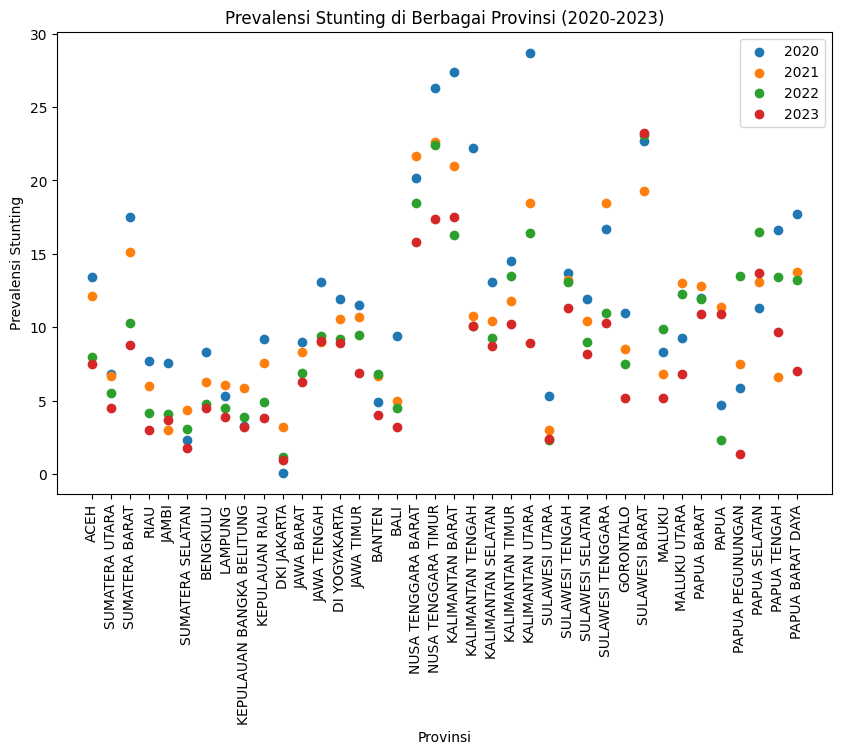

In [ ]:
import matplotlib.pyplot as plt

# Data
provinsi = ["ACEH", "SUMATERA UTARA", "SUMATERA BARAT", "RIAU", "JAMBI", "SUMATERA SELATAN", "BENGKULU",
            "LAMPUNG", "KEPULAUAN BANGKA BELITUNG", "KEPULAUAN RIAU", "DKI JAKARTA", "JAWA BARAT",
            "JAWA TENGAH", "DI YOGYAKARTA", "JAWA TIMUR", "BANTEN", "BALI", "NUSA TENGGARA BARAT",
            "NUSA TENGGARA TIMUR", "KALIMANTAN BARAT", "KALIMANTAN TENGAH", "KALIMANTAN SELATAN",
            "KALIMANTAN TIMUR", "KALIMANTAN UTARA", "SULAWESI UTARA", "SULAWESI TENGAH", "SULAWESI SELATAN",
            "SULAWESI TENGGARA", "GORONTALO", "SULAWESI BARAT", "MALUKU", "MALUKU UTARA", "PAPUA BARAT",
            "PAPUA", "PAPUA PEGUNUNGAN", "PAPUA SELATAN", "PAPUA TENGAH", "PAPUA BARAT DAYA"]

tahun_2020 = [13.4, 6.8, 17.5, 7.7, 7.6, 2.3, 8.3, 5.3, 3.3, 9.2, 0.1, 9.0, 13.1, 11.9, 11.5, 4.9, 9.4,
              20.2, 26.3, 27.4, 22.2, 13.1, 14.5, 28.7, 5.3, 13.7, 11.9, 16.7, 11.0, 22.7, 8.3, 9.3, 12.0,
              4.7, 5.9, 11.3, 16.6, 17.7]

tahun_2021 = [12.1, 6.7, 15.1, 6.0, 3.0, 4.4, 6.3, 6.1, 5.9, 7.6, 3.2, 8.3, 9.0, 10.6, 10.7, 6.7, 5.0,
              21.7, 22.6, 21.0, 10.8, 10.4, 11.8, 18.5, 3.0, 13.2, 10.4, 18.5, 8.5, 19.3, 6.8, 13.0, 12.8,
              11.4, 7.5, 13.1, 6.6, 13.8]

tahun_2022 = [8.0, 5.5, 10.3, 4.2, 4.1, 3.1, 4.8, 4.5, 3.9, 4.9, 1.2, 6.9, 9.4, 9.2, 9.5, 6.8, 4.5,
              18.5, 22.4, 16.3, 10.1, 9.3, 13.5, 16.4, 2.3, 13.1, 9.0, 11.0, 7.5, 23.1, 9.9, 12.3, 11.9,
              2.3, 13.5, 16.5, 13.4, 13.2]

tahun_2023 = [7.5, 4.5, 8.8, 3.0, 3.7, 1.8, 4.5, 3.9, 3.2, 3.8, 1.0, 6.3, 9.1, 8.9, 6.9, 4.0, 3.2,
              15.8, 17.4, 17.5, 10.1, 8.7, 10.2, 8.9, 2.4, 11.3, 8.2, 10.3, 5.2, 23.2, 5.2, 6.8, 10.9,
              10.9, 1.4, 13.7, 9.7, 7.0]

# Membuat scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(provinsi, tahun_2020, label='2020')
plt.scatter(provinsi, tahun_2021, label='2021')
plt.scatter(provinsi, tahun_2022, label='2022')
plt.scatter(provinsi, tahun_2023, label='2023')

# Menambahkan label sumbu dan judul
plt.xlabel('Provinsi')
plt.ylabel('Prevalensi Stunting')
plt.title('Prevalensi Stunting di Berbagai Provinsi (2020-2023)')

# Menambahkan legenda
plt.legend()

# Mengatur agar label sumbu x tidak tumpang tindih
plt.xticks(rotation=90)

# Menampilkan plot
plt.show()


In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_classification

# Generate synthetic data for binary classification
X, y = make_classification(n_samples=1000, n_features=10, n_classes=2, random_state=42)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Print the shapes of the training and testing sets
print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)


Shape of X_train: (800, 10)
Shape of X_test: (200, 10)
Shape of y_train: (800,)
Shape of y_test: (200,)


In [ ]:
from sklearn.preprocessing import MinMaxScaler

# Inisialisasi MinMaxScaler
scaler = MinMaxScaler()

# Melakukan scaling pada data training
X_train_scaled = scaler.fit_transform(X_train)

# Melakukan scaling pada data testing
X_test_scaled = scaler.transform(X_test)


In [ ]:
from sklearn.preprocessing import StandardScaler

# Inisialisasi StandardScaler
scaler = StandardScaler()

# Melakukan scaling pada data training
X_train_scaled = scaler.fit_transform(X_train)

# Melakukan scaling pada data testing
X_test_scaled = scaler.transform(X_test)


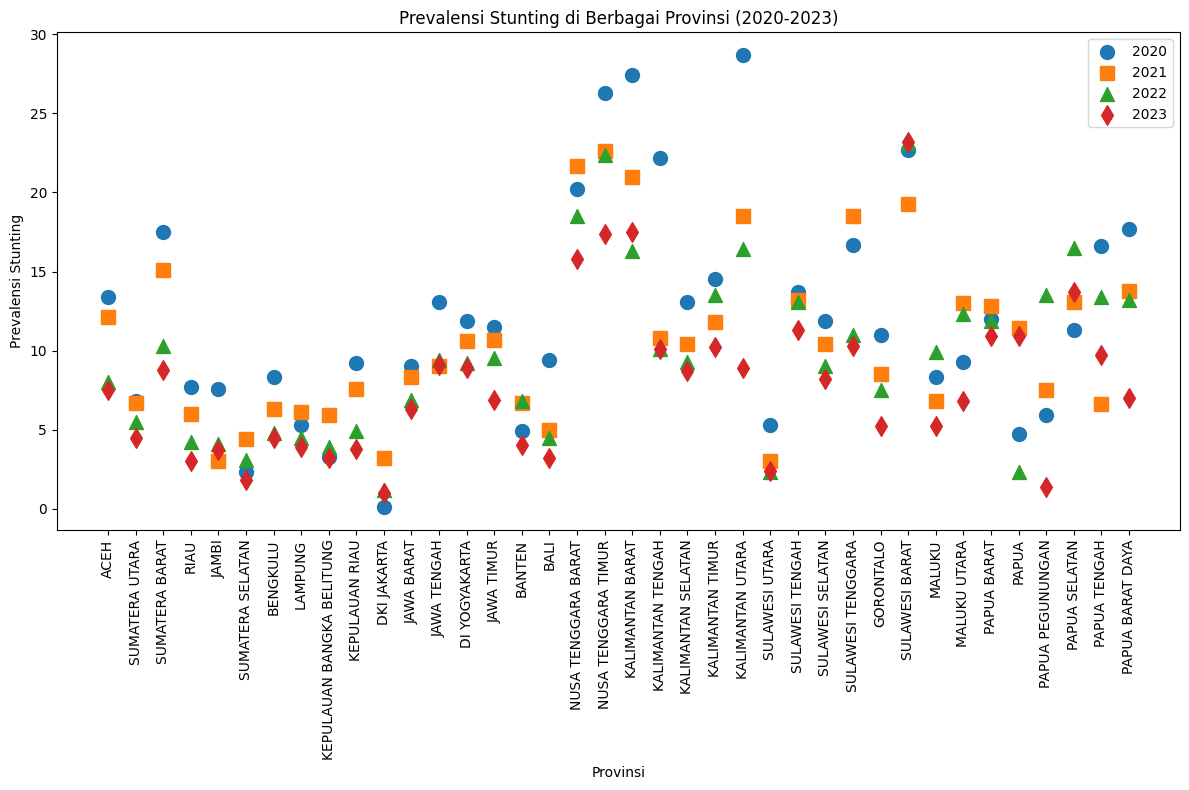

In [ ]:
import matplotlib.pyplot as plt

# Data Provinsi dan Prevalensi Stunting
provinsi = ["ACEH", "SUMATERA UTARA", "SUMATERA BARAT", "RIAU", "JAMBI", "SUMATERA SELATAN", "BENGKULU",
            "LAMPUNG", "KEPULAUAN BANGKA BELITUNG", "KEPULAUAN RIAU", "DKI JAKARTA", "JAWA BARAT",
            "JAWA TENGAH", "DI YOGYAKARTA", "JAWA TIMUR", "BANTEN", "BALI", "NUSA TENGGARA BARAT",
            "NUSA TENGGARA TIMUR", "KALIMANTAN BARAT", "KALIMANTAN TENGAH", "KALIMANTAN SELATAN",
            "KALIMANTAN TIMUR", "KALIMANTAN UTARA", "SULAWESI UTARA", "SULAWESI TENGAH", "SULAWESI SELATAN",
            "SULAWESI TENGGARA", "GORONTALO", "SULAWESI BARAT", "MALUKU", "MALUKU UTARA", "PAPUA BARAT",
            "PAPUA", "PAPUA PEGUNUNGAN", "PAPUA SELATAN", "PAPUA TENGAH", "PAPUA BARAT DAYA"]

prevalensi_2020 = [13.4, 6.8, 17.5, 7.7, 7.6, 2.3, 8.3, 5.3, 3.3, 9.2, 0.1, 9.0, 13.1, 11.9, 11.5, 4.9, 9.4,
                  20.2, 26.3, 27.4, 22.2, 13.1, 14.5, 28.7, 5.3, 13.7, 11.9, 16.7, 11.0, 22.7, 8.3, 9.3, 12.0,
                  4.7, 5.9, 11.3, 16.6, 17.7]

prevalensi_2021 = [12.1, 6.7, 15.1, 6.0, 3.0, 4.4, 6.3, 6.1, 5.9, 7.6, 3.2, 8.3, 9.0, 10.6, 10.7, 6.7, 5.0,
                  21.7, 22.6, 21.0, 10.8, 10.4, 11.8, 18.5, 3.0, 13.2, 10.4, 18.5, 8.5, 19.3, 6.8, 13.0, 12.8,
                  11.4, 7.5, 13.1, 6.6, 13.8]

prevalensi_2022 = [8.0, 5.5, 10.3, 4.2, 4.1, 3.1, 4.8, 4.5, 3.9, 4.9, 1.2, 6.9, 9.4, 9.2, 9.5, 6.8, 4.5,
                  18.5, 22.4, 16.3, 10.1, 9.3, 13.5, 16.4, 2.3, 13.1, 9.0, 11.0, 7.5, 23.1, 9.9, 12.3, 11.9,
                  2.3, 13.5, 16.5, 13.4, 13.2]

prevalensi_2023 = [7.5, 4.5, 8.8, 3.0, 3.7, 1.8, 4.5, 3.9, 3.2, 3.8, 1.0, 6.3, 9.1, 8.9, 6.9, 4.0, 3.2,
                  15.8, 17.4, 17.5, 10.1, 8.7, 10.2, 8.9, 2.4, 11.3, 8.2, 10.3, 5.2, 23.2, 5.2, 6.8, 10.9,
                  10.9, 1.4, 13.7, 9.7, 7.0]

# Membuat scatter plot
plt.figure(figsize=(12, 8))
plt.scatter(provinsi, prevalensi_2020, label='2020', marker='o', s=100)
plt.scatter(provinsi, prevalensi_2021, label='2021', marker='s', s=100)
plt.scatter(provinsi, prevalensi_2022, label='2022', marker='^', s=100)
plt.scatter(provinsi, prevalensi_2023, label='2023', marker='d', s=100)

# Menambahkan label sumbu dan judul
plt.xlabel('Provinsi')
plt.ylabel('Prevalensi Stunting')
plt.title('Prevalensi Stunting di Berbagai Provinsi (2020-2023)')

# Menambahkan legenda
plt.legend()

# Mengatur agar label sumbu x tidak tumpang tindih
plt.xticks(rotation=90)

# Menampilkan plot
plt.tight_layout()
plt.show()


                     Provinsi  Prevalensi_2020  Cluster
0                        ACEH             13.4        0
1              SUMATERA UTARA              6.8        2
2              SUMATERA BARAT             17.5        0
3                        RIAU              7.7        2
4                       JAMBI              7.6        2
5            SUMATERA SELATAN              2.3        2
6                    BENGKULU              8.3        2
7                     LAMPUNG              5.3        2
8   KEPULAUAN BANGKA BELITUNG              3.3        2
9              KEPULAUAN RIAU              9.2        2
10                DKI JAKARTA              0.1        2
11                 JAWA BARAT              9.0        2
12                JAWA TENGAH             13.1        0
13              DI YOGYAKARTA             11.9        0
14                 JAWA TIMUR             11.5        0
15                     BANTEN              4.9        2
16                       BALI              9.4  

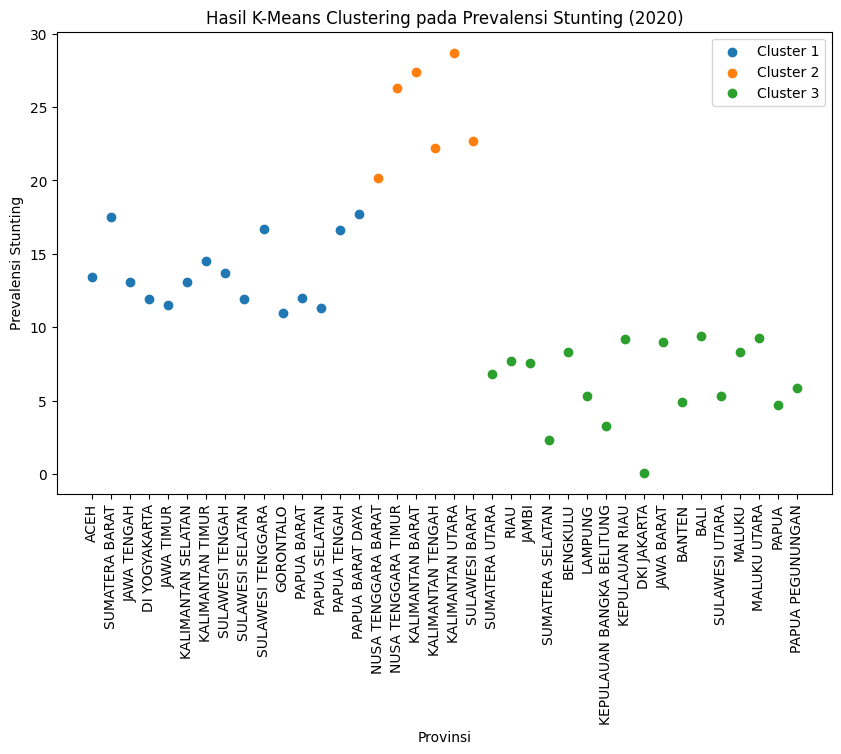

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Data
provinsi = ["ACEH", "SUMATERA UTARA", "SUMATERA BARAT", "RIAU", "JAMBI", "SUMATERA SELATAN", "BENGKULU",
            "LAMPUNG", "KEPULAUAN BANGKA BELITUNG", "KEPULAUAN RIAU", "DKI JAKARTA", "JAWA BARAT",
            "JAWA TENGAH", "DI YOGYAKARTA", "JAWA TIMUR", "BANTEN", "BALI", "NUSA TENGGARA BARAT",
            "NUSA TENGGARA TIMUR", "KALIMANTAN BARAT", "KALIMANTAN TENGAH", "KALIMANTAN SELATAN",
            "KALIMANTAN TIMUR", "KALIMANTAN UTARA", "SULAWESI UTARA", "SULAWESI TENGAH", "SULAWESI SELATAN",
            "SULAWESI TENGGARA", "GORONTALO", "SULAWESI BARAT", "MALUKU", "MALUKU UTARA", "PAPUA BARAT",
            "PAPUA", "PAPUA PEGUNUNGAN", "PAPUA SELATAN", "PAPUA TENGAH", "PAPUA BARAT DAYA"]

prevalensi_2020 = [13.4, 6.8, 17.5, 7.7, 7.6, 2.3, 8.3, 5.3, 3.3, 9.2, 0.1, 9.0, 13.1, 11.9, 11.5, 4.9, 9.4,
                  20.2, 26.3, 27.4, 22.2, 13.1, 14.5, 28.7, 5.3, 13.7, 11.9, 16.7, 11.0, 22.7, 8.3, 9.3, 12.0,
                  4.7, 5.9, 11.3, 16.6, 17.7]

# Menggunakan hanya data tahun 2020 untuk analisis clustering
X = np.array(prevalensi_2020).reshape(-1, 1)

# Standard Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Menentukan jumlah cluster yang optimal (misalnya, dari metode siku)
n_clusters = 3

# Melakukan k-means clustering
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
kmeans.fit(X_scaled)

# Menambahkan kolom cluster ke data
cluster_labels = kmeans.labels_

# Membuat DataFrame hasil clustering
result_df = pd.DataFrame({'Provinsi': provinsi, 'Prevalensi_2020': prevalensi_2020, 'Cluster': cluster_labels})

# Menampilkan hasil clustering
print(result_df)

# Visualisasi hasil clustering
plt.figure(figsize=(10, 6))
for cluster in range(n_clusters):
    cluster_data = result_df[result_df['Cluster'] == cluster]
    plt.scatter(cluster_data['Provinsi'], cluster_data['Prevalensi_2020'], label=f'Cluster {cluster + 1}')

plt.title('Hasil K-Means Clustering pada Prevalensi Stunting (2020)')
plt.xlabel('Provinsi')
plt.ylabel('Prevalensi Stunting')
plt.legend()
plt.xticks(rotation=90)
plt.show()



                     Provinsi  Prevalensi_2021  Cluster_2021
0                        ACEH             12.1             0
1              SUMATERA UTARA              6.7             1
2              SUMATERA BARAT             15.1             0
3                        RIAU              6.0             1
4                       JAMBI              3.0             1
5            SUMATERA SELATAN              4.4             1
6                    BENGKULU              6.3             1
7                     LAMPUNG              6.1             1
8   KEPULAUAN BANGKA BELITUNG              5.9             1
9              KEPULAUAN RIAU              7.6             1
10                DKI JAKARTA              3.2             1
11                 JAWA BARAT              8.3             1
12                JAWA TENGAH              9.0             1
13              DI YOGYAKARTA             10.6             0
14                 JAWA TIMUR             10.7             0
15                     B

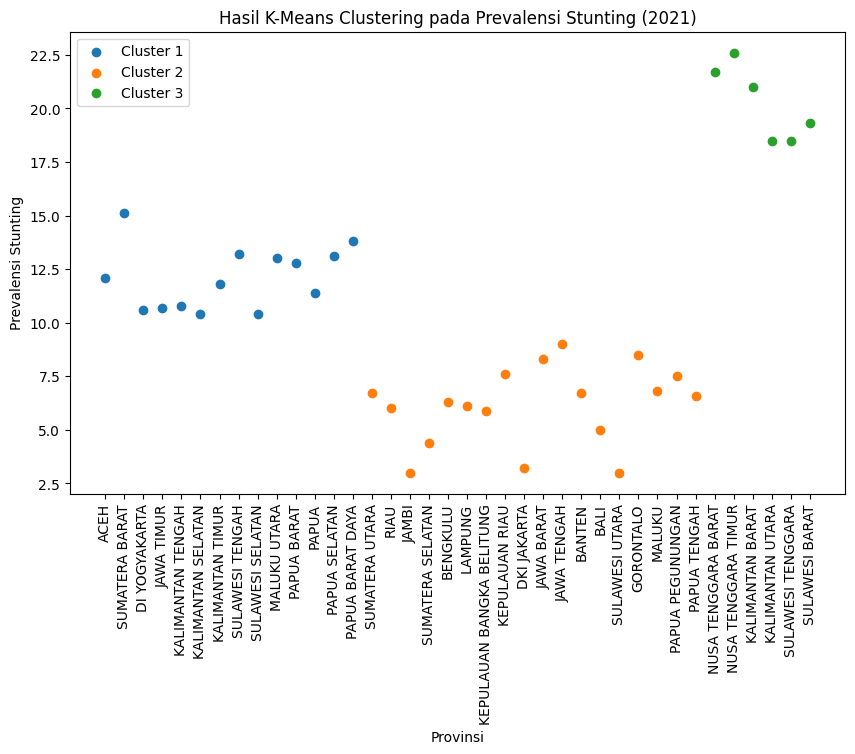

In [ ]:
# Menggunakan hanya data tahun 2021 untuk analisis clustering
X_2021 = np.array(prevalensi_2021).reshape(-1, 1)

# Standard Scaling
X_2021_scaled = scaler.transform(X_2021)

# Melakukan k-means clustering
kmeans_2021 = KMeans(n_clusters=n_clusters, random_state=42)
kmeans_2021.fit(X_2021_scaled)

# Menambahkan kolom cluster ke data
cluster_labels_2021 = kmeans_2021.labels_

# Membuat DataFrame hasil clustering untuk tahun 2021
result_df_2021 = pd.DataFrame({'Provinsi': provinsi, 'Prevalensi_2021': prevalensi_2021, 'Cluster_2021': cluster_labels_2021})

# Menampilkan hasil clustering untuk tahun 2021
print(result_df_2021)

# Visualisasi hasil clustering untuk tahun 2021
plt.figure(figsize=(10, 6))
for cluster in range(n_clusters):
    cluster_data = result_df_2021[result_df_2021['Cluster_2021'] == cluster]
    plt.scatter(cluster_data['Provinsi'], cluster_data['Prevalensi_2021'], label=f'Cluster {cluster + 1}')

plt.title('Hasil K-Means Clustering pada Prevalensi Stunting (2021)')
plt.xlabel('Provinsi')
plt.ylabel('Prevalensi Stunting')
plt.legend()
plt.xticks(rotation=90)
plt.show()


                     Provinsi  Prevalensi_2022  Cluster_2022
0                        ACEH              8.0             2
1              SUMATERA UTARA              5.5             0
2              SUMATERA BARAT             10.3             2
3                        RIAU              4.2             0
4                       JAMBI              4.1             0
5            SUMATERA SELATAN              3.1             0
6                    BENGKULU              4.8             0
7                     LAMPUNG              4.5             0
8   KEPULAUAN BANGKA BELITUNG              3.9             0
9              KEPULAUAN RIAU              4.9             0
10                DKI JAKARTA              1.2             0
11                 JAWA BARAT              6.9             0
12                JAWA TENGAH              9.4             2
13              DI YOGYAKARTA              9.2             2
14                 JAWA TIMUR              9.5             2
15                     B

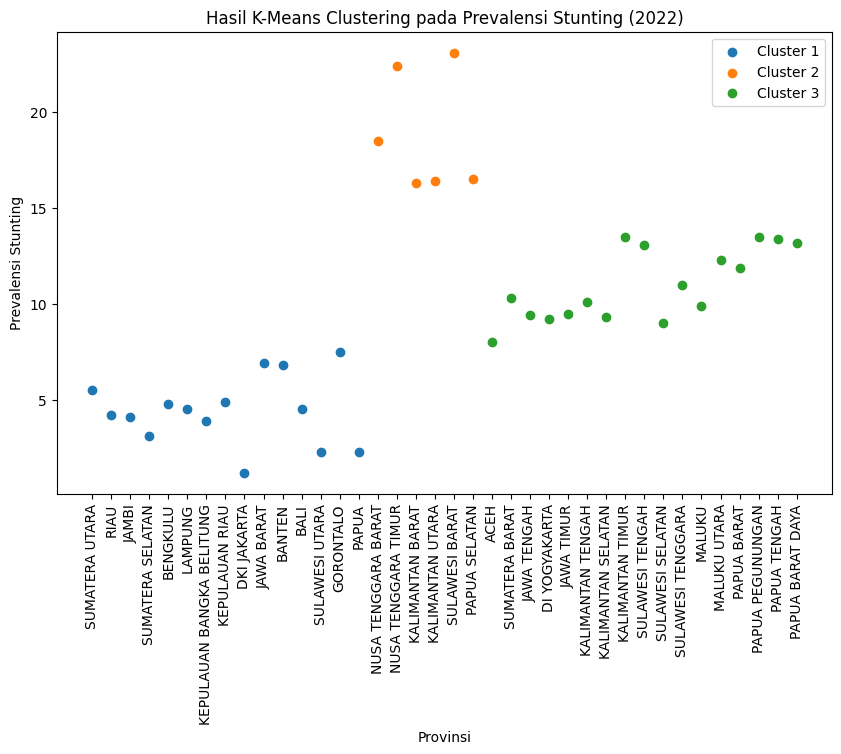

In [ ]:
# Menggunakan hanya data tahun 2022 untuk analisis clustering
X_2022 = np.array(prevalensi_2022).reshape(-1, 1)

# Standard Scaling
X_2022_scaled = scaler.transform(X_2022)

# Melakukan k-means clustering
kmeans_2022 = KMeans(n_clusters=n_clusters, random_state=42)
kmeans_2022.fit(X_2022_scaled)

# Menambahkan kolom cluster ke data
cluster_labels_2022 = kmeans_2022.labels_

# Membuat DataFrame hasil clustering untuk tahun 2022
result_df_2022 = pd.DataFrame({'Provinsi': provinsi, 'Prevalensi_2022': prevalensi_2022, 'Cluster_2022': cluster_labels_2022})

# Menampilkan hasil clustering untuk tahun 2022
print(result_df_2022)

# Visualisasi hasil clustering untuk tahun 2022
plt.figure(figsize=(10, 6))
for cluster in range(n_clusters):
    cluster_data = result_df_2022[result_df_2022['Cluster_2022'] == cluster]
    plt.scatter(cluster_data['Provinsi'], cluster_data['Prevalensi_2022'], label=f'Cluster {cluster + 1}')

plt.title('Hasil K-Means Clustering pada Prevalensi Stunting (2022)')
plt.xlabel('Provinsi')
plt.ylabel('Prevalensi Stunting')
plt.legend()
plt.xticks(rotation=90)
plt.show()



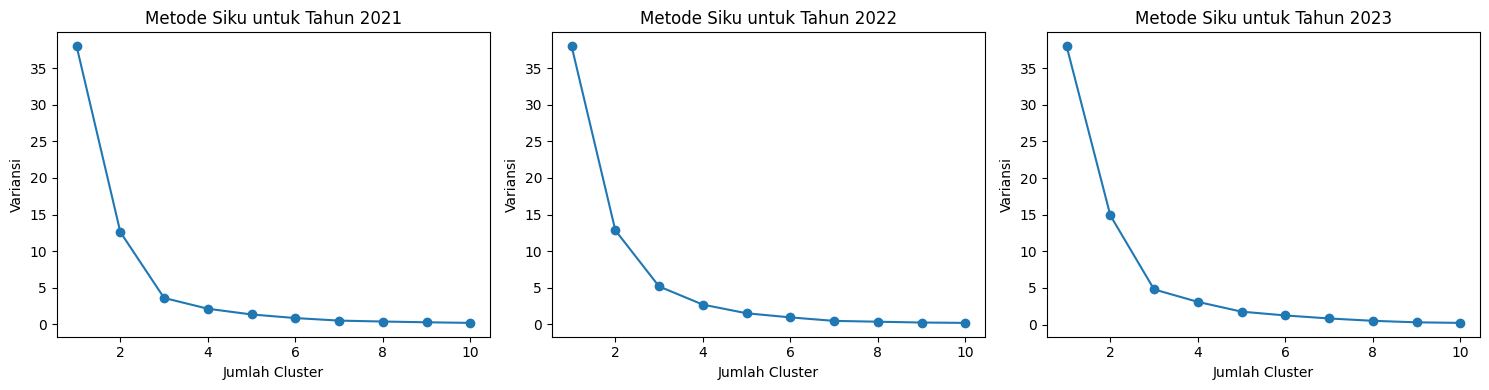

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Data untuk tahun 2021, 2022, dan 2023
X_2021 = np.array(prevalensi_2021).reshape(-1, 1)
X_2022 = np.array(prevalensi_2022).reshape(-1, 1)
X_2023 = np.array(prevalensi_2023).reshape(-1, 1)

# Standard Scaling untuk masing-masing tahun
scaler_2021 = StandardScaler()
X_2021_scaled = scaler_2021.fit_transform(X_2021)

scaler_2022 = StandardScaler()
X_2022_scaled = scaler_2022.fit_transform(X_2022)

scaler_2023 = StandardScaler()
X_2023_scaled = scaler_2023.fit_transform(X_2023)

# Menentukan jumlah cluster yang optimal (misalnya, dari metode siku)
def elbow_method(X_scaled):
    variance = []
    for i in range(1, 11):
        kmeans = KMeans(n_clusters=i, random_state=42)
        kmeans.fit(X_scaled)
        variance.append(kmeans.inertia_)
    return variance

# Menggunakan metode siku untuk masing-masing tahun
variance_2021 = elbow_method(X_2021_scaled)
variance_2022 = elbow_method(X_2022_scaled)
variance_2023 = elbow_method(X_2023_scaled)

# Plot metode siku untuk tahun 2021
plt.figure(figsize=(15, 4))
plt.subplot(1, 3, 1)
plt.plot(range(1, 11), variance_2021, marker='o')
plt.title('Metode Siku untuk Tahun 2021')
plt.xlabel('Jumlah Cluster')
plt.ylabel('Variansi')

# Plot metode siku untuk tahun 2022
plt.subplot(1, 3, 2)
plt.plot(range(1, 11), variance_2022, marker='o')
plt.title('Metode Siku untuk Tahun 2022')
plt.xlabel('Jumlah Cluster')
plt.ylabel('Variansi')

# Plot metode siku untuk tahun 2023
plt.subplot(1, 3, 3)
plt.plot(range(1, 11), variance_2023, marker='o')
plt.title('Metode Siku untuk Tahun 2023')
plt.xlabel('Jumlah Cluster')
plt.ylabel('Variansi')

plt.tight_layout()
plt.show()



Kesimpulan akhir untuk presentasi
Kalau sampai slide terakhir, kamu bisa membaca ini:
“Berdasarkan analisis yang dilakukan menggunakan metode K-Means, data prevalensi stunting dari 38 provinsi dikelompokkan menjadi tiga cluster, yaitu kelompok rendah, sedang, dan tinggi. Hasil analisis tahun 2020 sampai 2023 menunjukkan bahwa prevalensi stunting pada banyak provinsi mengalami kecenderungan penurunan. Namun, terdapat beberapa provinsi yang masih memiliki prevalensi relatif tinggi. Dengan adanya clustering ini, kita dapat mengetahui kelompok provinsi yang memiliki karakteristik prevalensi stunting yang serupa dan melihat perubahan kelompok tersebut dari tahun ke tahun.”